In [12]:
# Installation of Libraries 

!pip install seaborn xgboost shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\rushi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
# 1. Importing Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

import shap

# sns.set(style="whitegrid", palette="muted", font_scale=1.1)

In [14]:
df = pd.read_csv("CO2 Emissions_Canada.csv")

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


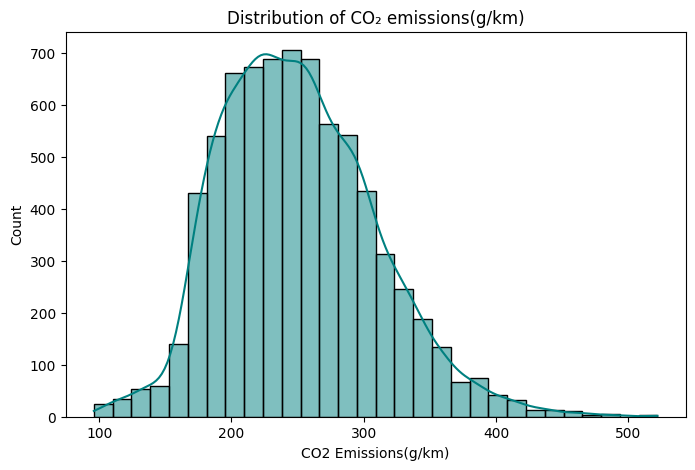

In [15]:
# Emissions distribution
plt.figure(figsize=(8,5))
sns.histplot(df["CO2 Emissions(g/km)"], bins=30, kde=True, color="teal")
plt.title("Distribution of CO₂ emissions(g/km)")
plt.show()

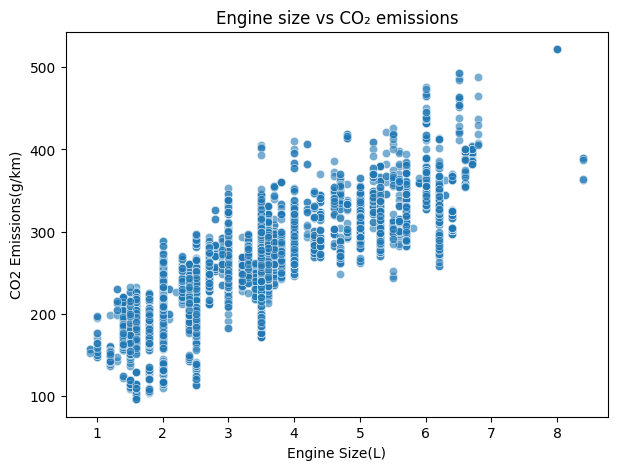

In [16]:
# Engine size vs. emissions
plt.figure(figsize=(7,5))
sns.scatterplot(x="Engine Size(L)", y="CO2 Emissions(g/km)", data=df, alpha=0.6)
plt.title("Engine size vs CO₂ emissions")
plt.show()

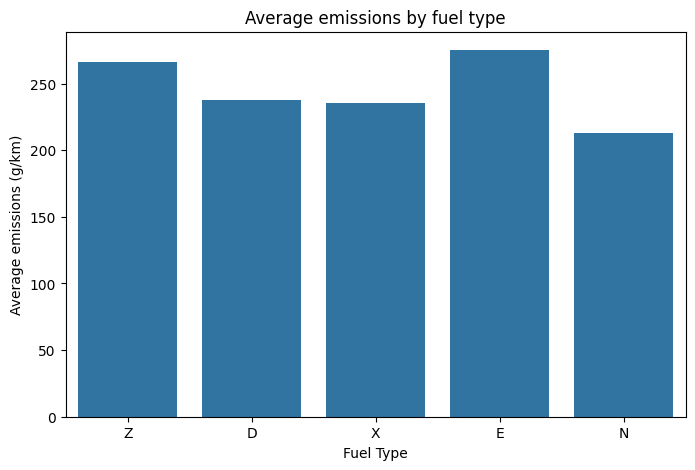

In [17]:
# Average emissions by fuel type
plt.figure(figsize=(8,5))
sns.barplot(x="Fuel Type", y="CO2 Emissions(g/km)", data=df, errorbar=None)
plt.title("Average emissions by fuel type")
plt.ylabel("Average emissions (g/km)")
plt.show()

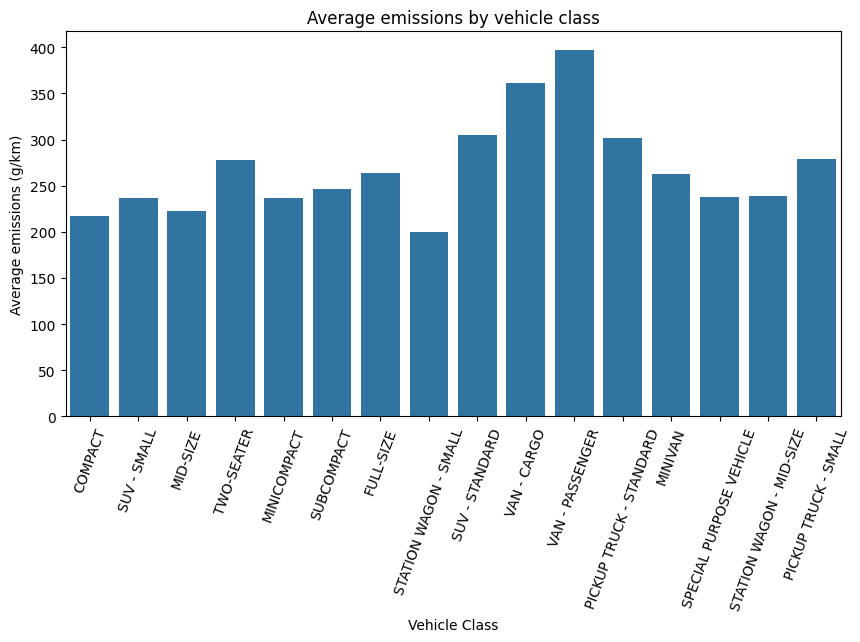

In [18]:
# Average emissions by vehicle class
plt.figure(figsize=(10,5))
sns.barplot(x="Vehicle Class", y="CO2 Emissions(g/km)", data=df, errorbar=None)
plt.title("Average emissions by vehicle class")
plt.xticks(rotation=70)
plt.ylabel("Average emissions (g/km)")
plt.show()

In [19]:
X = df[['Engine Size(L)', 'Cylinders', 'Fuel Type', 'Transmission']]
y = df['CO2 Emissions(g/km)']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# XGBoost
xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

C:\Users\rushi\AppData\Local\Temp\ipykernel_17756\3467984199.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")


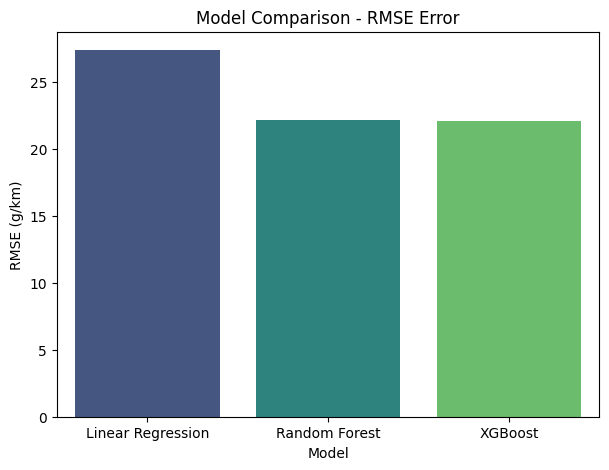

,Model,RMSE
0,Linear Regression,27.346615
1,Random Forest,22.148660
2,XGBoost,22.080614


In [21]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse]
})

plt.figure(figsize=(7,5))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")
plt.title("Model Comparison - RMSE Error")
plt.ylabel("RMSE (g/km)")
plt.show()

results_df